In [1]:
import sys
!{sys.executable} -m pip install numpy matplotlib


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip



=== Table 1: Pb vs N ===
N   ρ=0.5   ρ=1   ρ=2   ρ=3   ρ=4   ρ=5   ρ=6   ρ=8
4    0.00157978   0.0153846   0.0952381   0.206107   0.31068   0.398343   0.469565   0.574635
5    0.000157953   0.00306748   0.0366972   0.110054   0.199067   0.284868   0.3604   0.479008
6    1.31626e-05   0.000510986   0.0120846   0.0521571   0.117162   0.191847   0.264922   0.389752
7    9.40183e-07   7.29927e-05   0.00344086   0.0218643   0.0627489   0.120519   0.185055   0.308165
8    5.87614e-08   9.124e-06   0.000859476   0.00813244   0.0304201   0.0700479   0.121876   0.23557
9    3.26452e-09   1.01378e-06   0.000190958   0.00270348   0.0133397   0.0374578   0.075145   0.173141
10   1.63226e-10   1.01378e-07   3.81902e-05   0.000810388   0.00530755   0.0183846   0.0431418   0.121661
11   7.41937e-12   9.21616e-09   6.94362e-06   0.000220966   0.0019263   0.00828737   0.0229909   0.0812883
12   3.0914e-13   7.68013e-10   1.15727e-06   5.52385e-05   0.000641688   0.00344119   0.0113648   0.0514064
13  

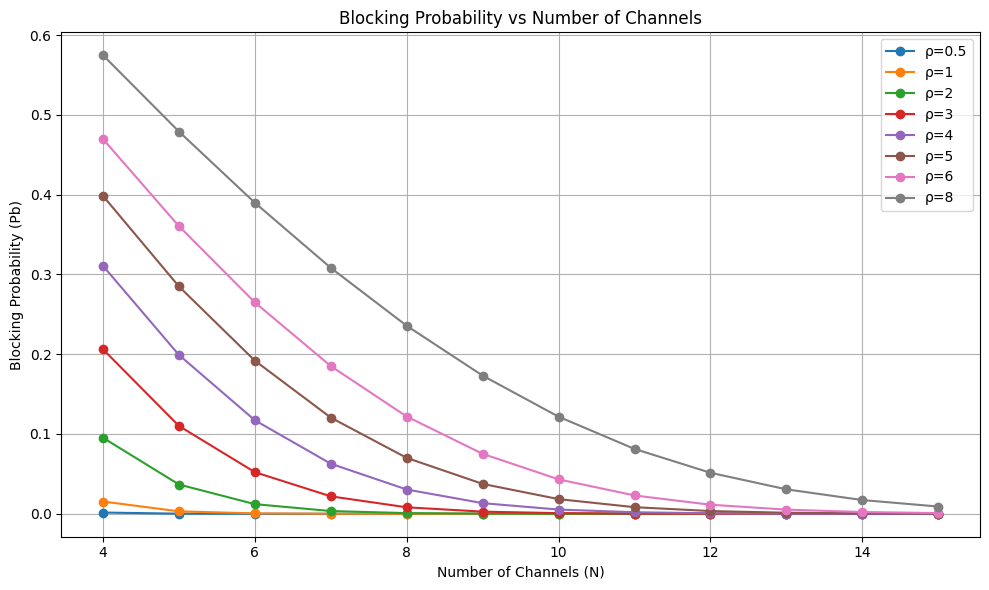

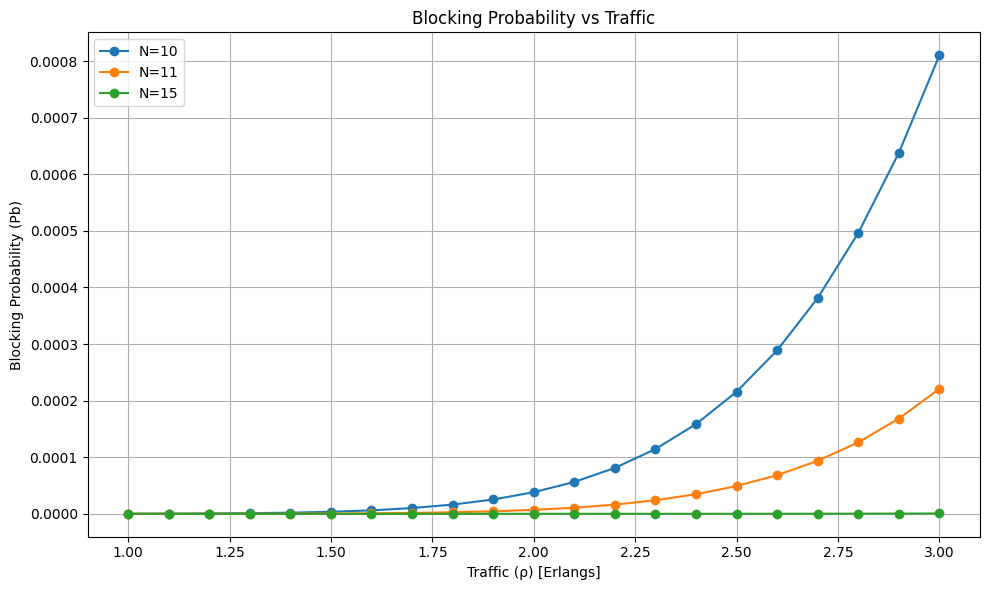

In [2]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def erlang_b(n: int, rho: float) -> float:
    """
    Blocking probability using Erlang-B formula.
    Stable recursive implementation.
    """
    if n < 0:
        raise ValueError("n must be >= 0")
    if rho < 0:
        raise ValueError("rho must be >= 0")

    b = 1.0
    for k in range(1, n + 1):
        b = (rho * b) / (k + rho * b)
    return b


def find_supported_traffic(n: int, target_pb: float, rho_max: float = 20.0, step: float = 0.01):
    """
    Finds the largest rho such that Erlang-B <= target_pb.
    Step of 0.01 chosen to match the report values closely.
    """
    best_rho = 0.0
    best_pb = erlang_b(n, 0.0)

    rho = 0.0
    while rho <= rho_max:
        pb = erlang_b(n, rho)
        if pb <= target_pb:
            best_rho = rho
            best_pb = pb
        else:
            break
        rho = round(rho + step, 10)

    return round(best_rho, 2), best_pb


def plot_pb_vs_channels():
    """
    Report section 1(a):
    Pb as function of number of channels N,
    for rho = 0.5, 1, 2, 3, 4, 5, 6, 8 and N = 4..15.
    """
    channels = np.arange(4, 16)
    traffic_values = [0.5, 1, 2, 3, 4, 5, 6, 8]

    plt.figure(figsize=(10, 6))
    for rho in traffic_values:
        pb_values = [erlang_b(n, rho) for n in channels]
        plt.plot(channels, pb_values, marker="o", label=f"ρ={rho}")

    plt.title("Blocking Probability vs Number of Channels")
    plt.xlabel("Number of Channels (N)")
    plt.ylabel("Blocking Probability (Pb)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig("pb_vs_channels.png", dpi=200)
    plt.show()


def plot_pb_vs_traffic():
    """
    Report section 1(b):
    Pb as function of traffic rho,
    for N = 10, 11, 15 and rho = 1..3.
    """
    rho_values = np.arange(1.0, 3.01, 0.1)
    channel_values = [10, 11, 15]

    plt.figure(figsize=(10, 6))
    for n in channel_values:
        pb_values = [erlang_b(n, rho) for rho in rho_values]
        plt.plot(rho_values, pb_values, marker="o", label=f"N={n}")

    plt.title("Blocking Probability vs Traffic")
    plt.xlabel("Traffic (ρ) [Erlangs]")
    plt.ylabel("Blocking Probability (Pb)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig("pb_vs_traffic.png", dpi=200)
    plt.show()


def print_report_tables():
    """
    Prints values in the same spirit as the report.
    """
    print("\n=== Table 1: Pb vs N ===")
    traffic_values = [0.5, 1, 2, 3, 4, 5, 6, 8]
    header = "N   " + "   ".join([f"ρ={rho}" for rho in traffic_values])
    print(header)

    for n in range(4, 16):
        row = [f"{n:<2}"]
        for rho in traffic_values:
            row.append(f"{erlang_b(n, rho):.6g}")
        print("   ".join(row))

    print("\n=== Table 2: Pb vs ρ ===")
    rho_values = np.arange(1.0, 3.01, 0.1)
    header = "N   " + "   ".join([f"{rho:.1f}" for rho in rho_values])
    print(header)

    for n in [10, 11, 15]:
        row = [f"{n:<2}"]
        for rho in rho_values:
            row.append(f"{erlang_b(n, float(rho)):.6g}")
        print("   ".join(row))


def print_supported_traffic_results():
    """
    Matches the final values shown in the report.
    """
    print("\n=== Supported traffic for Pb_max = 2% ===")
    for n in [10, 11, 15]:
        rho, pb = find_supported_traffic(n, target_pb=0.02, rho_max=20.0, step=0.01)
        print(f"N={n}: rho ≈ {rho:.2f}, Pb ≈ {pb:.6f}")

    print("\n=== Supported traffic for N = 11 and Phf_max = 0.1% ===")
    rho, pb = find_supported_traffic(11, target_pb=0.001, rho_max=20.0, step=0.01)
    print(f"N=11: rho ≈ {rho:.2f}, Pb ≈ {pb:.6f}")


def save_results_to_txt(filename: str = "results.txt"):
    """
    Saves the key final values to a text file.
    """
    lines = []
    lines.append("Supported traffic for Pb_max = 2%")
    for n in [10, 11, 15]:
        rho, pb = find_supported_traffic(n, target_pb=0.02, rho_max=20.0, step=0.01)
        lines.append(f"N={n}: rho={rho:.2f}, Pb={pb:.6f}")

    rho, pb = find_supported_traffic(11, target_pb=0.001, rho_max=20.0, step=0.01)
    lines.append(f"N=11 with Phf_max=0.1%: rho={rho:.2f}, Pb={pb:.6f}")

    Path(filename).write_text("\n".join(lines), encoding="utf-8")


def main():
    print_report_tables()
    print_supported_traffic_results()
    save_results_to_txt()
    plot_pb_vs_channels()
    plot_pb_vs_traffic()


if __name__ == "__main__":
    main()